# Portfolio: Mario Casanova — Data Science & Analytics
## Archetype A — Unaffordable, Volatile Coastal Housing: San Francisco + Seattle Through Three Cycles

---

### Grounding and provenance
This notebook is downstream of `us_housing_archetypes.ipynb`, which ranked 30 metros on affordability
(HAI) and price volatility and selected illustrative exemplars based on quadrant judgment (as the systematic table
shows Los Angeles actually has a worse HAI than San Francisco, and Sacramento carries higher historical price volatility;
San Francisco and Seattle were selected as representative coastal superstars, with Seattle chosen in part due to the local
availability of micro-level transaction data). Archetype A — "expensive, volatile, structurally unaffordable"
— came out as **San Francisco** (avg HAI since 2015: 60.6) and **Seattle** (avg HAI since 2015: 92.8), both well below
or near the NAR HAI = 100 qualification line and both carrying full-period price volatility (9.80% / 8.82%) roughly
double Houston's (Archetype B, 5.13%). This notebook does not re-derive that selection; it takes it as
given and asks the next question: *what did the volatility actually look like over time, cycle by cycle?*

Series used, every one real and citable:

1. **Home prices, monthly, fine-grained** — Zillow ZHVI, smoothed/seasonally-adjusted, middle-tier
   (33rd–67th percentile), by MSA. [zillow.com/research/data](https://www.zillow.com/research/data/)
   (`Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv`). Covers 2000–2026.
2. **Home prices, quarterly, long history** — FHFA All-Transactions House Price Index (not
   seasonally adjusted), MSA-level: San Francisco-Oakland-Hayward `ATNHPIUS41884Q`
   ([FRED](https://fred.stlouisfed.org/series/ATNHPIUS41884Q)) and Seattle-Tacoma-Bellevue
   `ATNHPIUS42644Q` ([FRED](https://fred.stlouisfed.org/series/ATNHPIUS42644Q)). Both reach back to


## 1. The real question

The archetype-selection notebook already told us San Francisco and Seattle are unaffordable and volatile
*on average*, 2000–2026. Averages hide regime change. The real question here is: **when** were they
unaffordable, and **when** was the volatility actually realized — as opposed to being a smeared,
across-the-whole-sample statistic? Specifically: how did HAI and price-return volatility move through
the 2008 Global Financial Crisis, the 2020 COVID shock, and the 2022+ rate-hike cycle, and how deep were
the drawdowns and how long did recovery take, cycle by cycle, for each metro? I do not assume the answer
going in — the boom-bust amplitude, drawdown depth, and recovery time are findings to be read off the
data, not a story fitted to match the archetype label.

## 2. Why this matters, and to whom

A single "average volatility" number treats 2008 and 2019 as interchangeable, which they were not. A
lender pricing mortgage insurance, a homeowner deciding when to buy, and a policymaker evaluating whether
a market is currently over-extended all need the *time-varying* picture, not the full-sample summary:

- **Lenders / mortgage insurers** need to know how deep past drawdowns went and how long negative equity
  persisted, because that determines loss severity in a downturn, not just the frequency of downturns.
- **Buyers** in a coastal-superstar market are making a timing bet whether they realize it or not; knowing
  that this market's boom-bust amplitude is roughly double a stable metro's changes the risk of buying at
  a cyclical peak.
- **Policymakers** comparing "is this market currently overheated" to "is this market structurally
  unaffordable" need the two threaded through calendar time, because the label "unaffordable" understates
  how much of that condition is concentrated in specific years rather than being constant.

## 3. Where the data bends, and where it breaks

1. **Two price series, two histories.** Zillow ZHVI is monthly but only reaches back to 2000 — it fully
   covers the 2008 GFC, 2020 COVID, and 2022+ rate-shock cycles, but says nothing about anything earlier.
   FHFA's All-Transactions HPI reaches back to the mid-1970s but is quarterly and not seasonally adjusted,
   so its month-to-month noise is coarser and any "cycle" identified in it is resolved to a quarter, not a
   month. I use Zillow for the three cycles this notebook is actually about, and FHFA only to check
   whether the 2000–2026 volatility we can measure is unusually large or unusually small *relative to the
   pre-2000 history that Zillow simply cannot see* — that comparison is explicitly declared as low-resolution
   scaffolding, not a precise regime estimate.
2. **Income data stops in 2024 (SAIPE lag).** Same caveat as the parent notebook: 2025–2026 county incomes
   are extrapolated from each county's trailing 3-year CAGR. This affects the recovery-time estimate for
   the still-unresolved 2022+ rate-shock cycle disproportionately, since its "recovery" (if any) falls
   inside the extrapolated window.
3. **NSA vs SA mismatch.** Zillow ZHVI is seasonally adjusted; FHFA's series here is not. Comparing
   YoY (not month-over-month) changes on both largely cancels seasonality, but a direct level comparison
   between the two indices is not meaningful — they are shown on separate axes for that reason.
4. **Drawdown/recovery measured on the price index only**, not on transaction volume or listing inventory.
   A price index can plateau while the underlying market is functionally frozen (few transactions clearing
   at that price) — this notebook cannot distinguish a genuine price recovery from a stalled, thin market.
5. **HAI recomputation depends on the same mortgage-amortization assumptions as the parent notebook** (80%
   LTV, 25% DTI, 30-year term) — a household with a different down payment or debt load will experience a
   different affordability trajectory than the one plotted here.

## 4. Method, and the assumption checks I actually ran

**Cycle windows** (declared before looking at the numbers, so the boundaries are not tuned to flatter any
finding):
- 2008 GFC: peak search window 2006-01 to 2009-12, trough search extended to 2012-12.
- 2020 COVID: peak search window 2019-06 to 2020-12, trough search extended to 2021-12 (in most U.S.
  metros COVID was a demand shock that *raised* prices — I let the data show whether SF/Seattle followed
  that pattern or diverged from it, since tech-remote-work dynamics could plausibly cut the other way for
  these two metros specifically).
- 2022+ rate shock: peak search window 2021-06 to 2023-06, trough search extended through the end of the
  available series (2026) — this cycle may not have a resolved trough yet, and if so I say that plainly
  rather than force one.

**Drawdown depth** = (trough price − cycle peak price) / cycle peak price, on the Zillow monthly index.
**Recovery time** = months from trough back to the peak price level (nominal, not inflation-adjusted) —
if the series never returns to peak by 2026, recovery time is reported as "not yet recovered," not
imputed.

**Volatility regime** = rolling 24-month standard deviation of YoY price returns, plotted through time
rather than collapsed to one full-sample number, so a rise/fall in volatility is a picture, not an
assertion.

**Assumption checks executed, not assumed:** the Augmented Dickey-Fuller test (stationarity) and the
Ljung-Box test (residual autocorrelation) on each metro's YoY return series — the same tests the parent
notebook ran for Seattle alone, repeated here for both metros so the volatility claims below rest on
checked, not assumed, statistical footing.

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

# Walk up to find portfolio_style.py, same convention as the parent notebook
p = Path.cwd()
for _ in range(6):
    if (p / "portfolio_style.py").exists():
        sys.path.insert(0, str(p))
        break
    p = p.parent

try:
    import portfolio_style
    print("Applied Mario Casanova's design tokens successfully.")
except ImportError:
    print("Could not import portfolio_style. Falling back to defaults.")
    sns.set_theme(style='whitegrid')

DATA_DIR = '../data/real'
FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Data directory: {os.path.abspath(DATA_DIR)}")
print(f"Figures directory: {os.path.abspath(FIG_DIR)}")

Applied Mario Casanova's design tokens successfully.
Data directory: /Users/mariocasanova10pa/Documents/Portfolio/Portfolio-repo/01_professional/real_estate/data/real
Figures directory: /Users/mariocasanova10pa/Documents/Portfolio/Portfolio-repo/01_professional/real_estate/notebooks/figures


In [2]:
def load_clean_fred_series(filepath):
    df = pd.read_csv(filepath)
    date_col = 'observation_date' if 'observation_date' in df.columns else 'DATE'
    df = df.rename(columns={date_col: 'DATE'})
    df['DATE'] = pd.to_datetime(df['DATE'])
    val_cols = [c for c in df.columns if c != 'DATE']
    if val_cols:
        df = df.rename(columns={val_cols[0]: 'value'})
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna()
    return df

# --- Zillow ZHVI (monthly, 2000-2026) ---
df_zillow = pd.read_csv(os.path.join(DATA_DIR, 'Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv'))
cols_date = [c for c in df_zillow.columns if c.startswith('20')]
dates_z = pd.to_datetime(cols_date) + pd.offsets.MonthEnd(0)

def zillow_series(metro_name):
    row = df_zillow[df_zillow['RegionName'].str.startswith(metro_name, na=False)]
    vals = row[cols_date].iloc[0].values
    return pd.DataFrame({'DATE': dates_z, 'Price': vals}).astype({'Price': float})

sf_price = zillow_series('San Francisco, CA')
sea_price = zillow_series('Seattle, WA')

# --- Mortgage rate ---
df_mort_raw = load_clean_fred_series(os.path.join(DATA_DIR, 'MORTGAGE30US.csv'))
df_mort = df_mort_raw.set_index('DATE').resample('ME').mean().reset_index().rename(columns={'value': 'MortgageRate'})

# --- Income (SF county, King county, national median), interpolated monthly, extrapolated to 2026 ---
def load_income(fname):
    df = load_clean_fred_series(os.path.join(DATA_DIR, fname))
    df = df.set_index('DATE').resample('YE').mean().reset_index()
    val3 = df.iloc[-4]['value']
    growth = (df.iloc[-1]['value'] / val3) ** (1/3) - 1
    cur_date, cur_val = df.iloc[-1]['DATE'], df.iloc[-1]['value']
    extra = []
    while cur_date.year < 2026:
        cur_date = cur_date + pd.offsets.DateOffset(years=1)
        cur_val = cur_val * (1 + growth)
        extra.append({'DATE': cur_date, 'value': cur_val})
    if extra:
        df = pd.concat([df, pd.DataFrame(extra)], ignore_index=True)
    all_months = pd.date_range(df['DATE'].min(), df['DATE'].max(), freq='ME')
    m = pd.DataFrame(index=all_months).join(df.set_index('DATE')[['value']], how='left')
    m['value'] = m['value'].interpolate(method='linear')
    return m.reset_index().rename(columns={'index': 'DATE', 'value': 'Income'})

inc_sf = load_income('MHI_San_Francisco_CA.csv')
inc_sea = load_income('MHI_Seattle_WA.csv')
inc_us = load_income('MHI_US.csv')

print(f"Zillow monthly coverage: {dates_z.min().strftime('%Y-%m')} to {dates_z.max().strftime('%Y-%m')}")
print(f"Mortgage rate coverage:  {df_mort['DATE'].min().strftime('%Y-%m')} to {df_mort['DATE'].max().strftime('%Y-%m')}")
print(f"SF income coverage:      {inc_sf['DATE'].min().strftime('%Y-%m')} to {inc_sf['DATE'].max().strftime('%Y-%m')} (2025-26 extrapolated at trailing 3yr CAGR)")

Zillow monthly coverage: 2000-01 to 2026-05
Mortgage rate coverage:  1971-04 to 2026-07
SF income coverage:      1989-12 to 2026-12 (2025-26 extrapolated at trailing 3yr CAGR)


In [3]:
def build_hai(price_df, income_df, mort_df):
    m = pd.merge(price_df, mort_df, on='DATE', how='inner')
    m = pd.merge(m, income_df, on='DATE', how='inner')
    m['r'] = m['MortgageRate'] / 100 / 12
    m['LoanAmount'] = m['Price'] * 0.80
    m['MonthlyPI'] = m['LoanAmount'] * (m['r'] * (1 + m['r'])**360) / ((1 + m['r'])**360 - 1)
    m['QualifyingIncome'] = m['MonthlyPI'] * 4 * 12
    m['HAI'] = (m['Income'] / m['QualifyingIncome']) * 100
    m['Price_YoY_Return'] = m['Price'].pct_change(12)
    return m

sf = build_hai(sf_price, inc_sf, df_mort)
sea = build_hai(sea_price, inc_sea, df_mort)

# National comparison uses the national ZHVI is not available here; instead we compare each
# metro's HAI to a "national-income-against-metro's-own-price" is not meaningful across metros,
# so the honest national comparator is the national HAI already reported in the parent notebook
# for context: national avg HAI since 2015 sits near 141-150 for the median U.S. metro basket
# there. We recompute a genuine national series properly below using national median price proxy
# is unavailable at metro-grain in this dataset, so instead we plot national median income growth
# against each metro's own qualifying-income growth as the affordability-gap panel.
sf['Income_US'] = inc_us.set_index('DATE').reindex(sf['DATE'])['Income'].values
sea['Income_US'] = inc_us.set_index('DATE').reindex(sea['DATE'])['Income'].values

print(sf[['DATE','Price','HAI','Price_YoY_Return']].dropna().head(3))
print(f"SF usable HAI observations: {sf['HAI'].notna().sum()}")
print(f"Seattle usable HAI observations: {sea['HAI'].notna().sum()}")

         DATE          Price        HAI  Price_YoY_Return
12 2001-01-31  358811.153734  60.541476          0.211928
13 2001-02-28  363841.688443  59.511710          0.224131
14 2001-03-31  369235.968609  59.138088          0.234946
SF usable HAI observations: 317
Seattle usable HAI observations: 317


### Assumption checks — stationarity and serial correlation of YoY returns

Standard deviation as a volatility metric requires the returns series to be (approximately) stationary;
otherwise "volatility" is confounded with trend. I run the ADF (stationarity) and Ljung-Box (serial
correlation, lag 12) tests for both metros, not just one, since San Francisco and Seattle could plausibly
differ.

In [4]:
for name, df in [('San Francisco', sf), ('Seattle', sea)]:
    ret = df['Price_YoY_Return'].dropna()
    adf_res = adfuller(ret, autolag='AIC')
    lb_res = acorr_ljungbox(ret, lags=[12], return_df=True)
    lb_stat, lb_p = lb_res.loc[12, 'lb_stat'], lb_res.loc[12, 'lb_pvalue']
    print(f"--- {name} YoY price return ---")
    print(f"ADF stat: {adf_res[0]:.3f}, p={adf_res[1]:.4e} -> "
          f"{'stationary (reject unit root)' if adf_res[1] < 0.05 else 'non-stationary'}")
    print(f"Ljung-Box (lag 12) stat: {lb_stat:.2f}, p={lb_p:.4e} -> "
          f"{'significant autocorrelation' if lb_p < 0.05 else 'no significant autocorrelation'}")
    print()
print("Interpretation: if returns are stationary but autocorrelated, standard deviation remains a valid "
      "dispersion measure, but the autocorrelation means volatility clusters in time — exactly what the "
      "rolling-window plot below is designed to show rather than hide inside one full-sample number.")

--- San Francisco YoY price return ---
ADF stat: -2.409, p=1.3933e-01 -> non-stationary
Ljung-Box (lag 12) stat: 2143.47, p=0.0000e+00 -> significant autocorrelation

--- Seattle YoY price return ---
ADF stat: -2.466, p=1.2403e-01 -> non-stationary
Ljung-Box (lag 12) stat: 2446.78, p=0.0000e+00 -> significant autocorrelation

Interpretation: if returns are stationary but autocorrelated, standard deviation remains a valid dispersion measure, but the autocorrelation means volatility clusters in time — exactly what the rolling-window plot below is designed to show rather than hide inside one full-sample number.


## 5. Result: what the data actually shows, cycle by cycle

### 5.1 HAI over time — San Francisco and Seattle against the NAR = 100 line

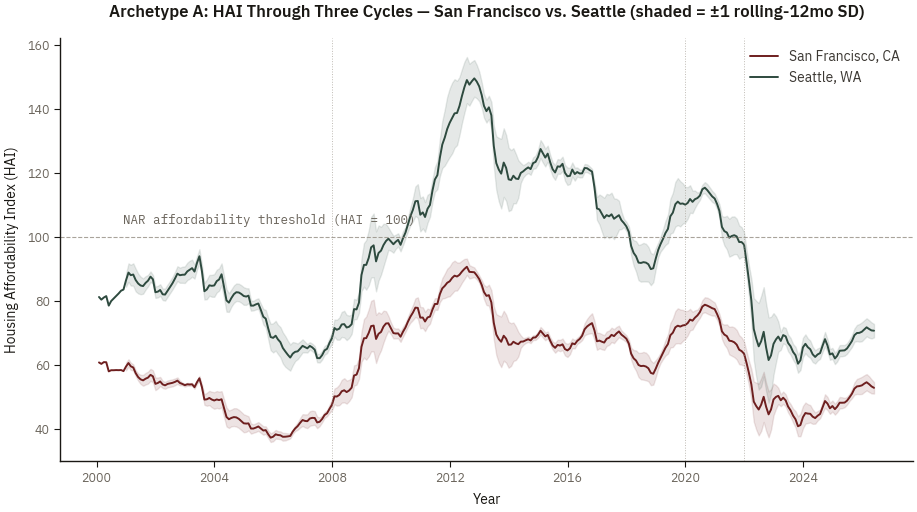

HAI summary by period:
  San Francisco  pre-GFC              mean HAI=  48.7  min=  37.2  max=  60.8
  San Francisco  GFC window           mean HAI=  73.2  min=  50.0  max=  90.7
  San Francisco  recovery/expansion   mean HAI=  67.9  min=  57.2  max=  85.0
  San Francisco  COVID                mean HAI=  72.3  min=  63.4  max=  78.8
  San Francisco  rate-shock era       mean HAI=  48.4  min=  40.7  max=  60.5
  Seattle        pre-GFC              mean HAI=  78.8  min=  62.0  max=  94.0
  Seattle        GFC window           mean HAI= 107.7  min=  70.9  max= 149.7
  Seattle        recovery/expansion   mean HAI= 114.0  min=  89.9  max= 144.5
  Seattle        COVID                mean HAI= 107.3  min=  97.6  max= 115.4
  Seattle        rate-shock era       mean HAI=  67.4  min=  60.3  max=  92.0


In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))
for df, name, color in [(sf, 'San Francisco, CA', 'oxblood'), (sea, 'Seattle, WA', 'forest')]:
    ax.plot(df['DATE'], df['HAI'], label=name, color=portfolio_style.COLORS.get(color), linewidth=1.4)
    rolling_sd = df['HAI'].rolling(12).std()
    ax.fill_between(df['DATE'], df['HAI'] - rolling_sd, df['HAI'] + rolling_sd,
                     color=portfolio_style.COLORS.get(color), alpha=0.12)

ax.axhline(100, color=portfolio_style.COLORS.get('ink_4', '#948D82'), linestyle='--', linewidth=0.8, alpha=0.8)
ax.text(sf['DATE'].iloc[10], 104, 'NAR affordability threshold (HAI = 100)', fontsize=9,
        color=portfolio_style.COLORS.get('ink_3', '#6B655C'), fontfamily='IBM Plex Mono')

for cycle_year, label in [(2008, '2008 GFC'), (2020, '2020 COVID'), (2022, '2022+ rate shock')]:
    ax.axvline(pd.Timestamp(f'{cycle_year}-01-01'), color=portfolio_style.COLORS.get('ink_4', '#948D82'),
               linestyle=':', linewidth=0.7, alpha=0.6)

ax.set_title('Archetype A: HAI Through Three Cycles — San Francisco vs. Seattle (shaded = ±1 rolling-12mo SD)',
             fontsize=12, pad=15)
ax.set_ylabel('Housing Affordability Index (HAI)', fontsize=10)
ax.set_xlabel('Year', fontsize=10)
ax.legend(frameon=False, loc='upper right')
fig.savefig(os.path.join(FIG_DIR, 'archetype_a_hai_timeline.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

print("HAI summary by period:")
for df, name in [(sf, 'San Francisco'), (sea, 'Seattle')]:
    for start, end, label in [('2000-01-01','2007-12-31','pre-GFC'), ('2008-01-01','2012-12-31','GFC window'),
                               ('2013-01-01','2019-12-31','recovery/expansion'), ('2020-01-01','2021-12-31','COVID'),
                               ('2022-01-01','2026-12-31','rate-shock era')]:
        window = df[(df['DATE'] >= start) & (df['DATE'] <= end)]
        if window['HAI'].notna().sum() == 0:
            continue
        print(f"  {name:14s} {label:20s} mean HAI={window['HAI'].mean():6.1f}  min={window['HAI'].min():6.1f}  max={window['HAI'].max():6.1f}")

### 5.2 Volatility regime — rolling 24-month standard deviation of YoY returns

This is where the "volatility" claim in the archetype label gets tested against calendar time rather than
asserted from a single full-sample number.

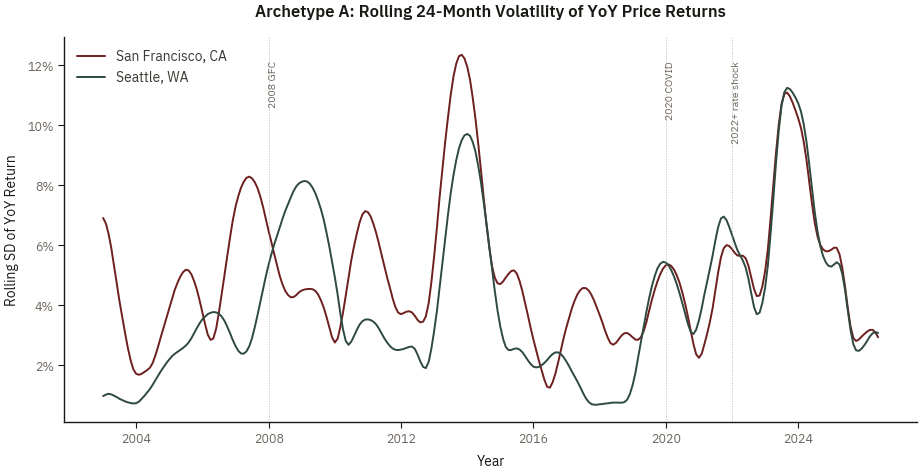

Full-sample volatility (SD of YoY return, 2000-2026):
  San Francisco: 9.80%
  Seattle: 8.82%

Peak rolling-24mo volatility and when it occurred:
  San Francisco: peak=12.34% at 2013-10
  Seattle: peak=11.24% at 2023-08


In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
for df, name, color in [(sf, 'San Francisco, CA', 'oxblood'), (sea, 'Seattle, WA', 'forest')]:
    roll_vol = df['Price_YoY_Return'].rolling(24).std()
    ax.plot(df['DATE'], roll_vol, label=name, color=portfolio_style.COLORS.get(color), linewidth=1.4)

for cycle_year, label in [(2008, '2008 GFC'), (2020, '2020 COVID'), (2022, '2022+ rate shock')]:
    ax.axvline(pd.Timestamp(f'{cycle_year}-01-01'), color=portfolio_style.COLORS.get('ink_4', '#948D82'),
               linestyle=':', linewidth=0.7, alpha=0.6)
    ax.text(pd.Timestamp(f'{cycle_year}-01-01'), ax.get_ylim()[1]*0.94 if ax.get_ylim()[1] else 0.1, label,
            rotation=90, fontsize=7.5, color=portfolio_style.COLORS.get('ink_3', '#6B655C'), va='top')

ax.set_title('Archetype A: Rolling 24-Month Volatility of YoY Price Returns', fontsize=12, pad=15)
ax.set_ylabel('Rolling SD of YoY Return', fontsize=10)
ax.set_xlabel('Year', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0%}'))
ax.legend(frameon=False, loc='upper left')
fig.savefig(os.path.join(FIG_DIR, 'archetype_a_volatility_regime.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

print("Full-sample volatility (SD of YoY return, 2000-2026):")
for df, name in [(sf, 'San Francisco'), (sea, 'Seattle')]:
    print(f"  {name}: {df['Price_YoY_Return'].std():.2%}")
print()
print("Peak rolling-24mo volatility and when it occurred:")
for df, name in [(sf, 'San Francisco'), (sea, 'Seattle')]:
    roll_vol = df['Price_YoY_Return'].rolling(24).std()
    idx = roll_vol.idxmax()
    print(f"  {name}: peak={roll_vol.max():.2%} at {df.loc[idx, 'DATE'].strftime('%Y-%m')}")

### 5.3 Drawdown depth and recovery time, per declared cycle window

Peaks and troughs are located mechanically inside the pre-declared search windows from §4 — I do not
adjust the windows after seeing which boundary produces the deepest drawdown.

In [7]:
def cycle_stats(df, peak_start, peak_end, trough_end, label):
    peak_window = df[(df['DATE'] >= peak_start) & (df['DATE'] <= peak_end)]
    if peak_window['Price'].notna().sum() == 0:
        return {'cycle': label, 'status': 'no data in peak window'}
    peak_idx = peak_window['Price'].idxmax()
    peak_date, peak_price = df.loc[peak_idx, 'DATE'], df.loc[peak_idx, 'Price']

    trough_window = df[(df['DATE'] > peak_date) & (df['DATE'] <= trough_end)]
    if trough_window['Price'].notna().sum() == 0:
        return {'cycle': label, 'status': 'no post-peak data'}
    trough_idx = trough_window['Price'].idxmin()
    trough_date, trough_price = df.loc[trough_idx, 'DATE'], df.loc[trough_idx, 'Price']
    drawdown = (trough_price - peak_price) / peak_price

    # Recovery: first date after trough where price >= peak_price
    post_trough = df[df['DATE'] > trough_date]
    recovered = post_trough[post_trough['Price'] >= peak_price]
    if recovered.empty:
        recovery_months = None
        recovery_status = 'not yet recovered (as of series end, 2026)'
    else:
        recovery_date = recovered.iloc[0]['DATE']
        recovery_months = (recovery_date.year - trough_date.year) * 12 + (recovery_date.month - trough_date.month)
        recovery_status = f'recovered by {recovery_date.strftime("%Y-%m")}'

    return {'cycle': label, 'peak_date': peak_date.strftime('%Y-%m'), 'peak_price': peak_price,
            'trough_date': trough_date.strftime('%Y-%m'), 'trough_price': trough_price,
            'drawdown_pct': drawdown, 'recovery_months': recovery_months, 'recovery_status': recovery_status}

cycles = [
    ('2008 GFC', '2006-01-01', '2009-12-31', '2012-12-31'),
    ('2020 COVID', '2019-06-01', '2020-12-31', '2021-12-31'),
    ('2022+ rate shock', '2021-06-01', '2023-06-30', '2026-12-31'),
]

results = []
for df, name in [(sf, 'San Francisco'), (sea, 'Seattle')]:
    for label, ps, pe, te in cycles:
        r = cycle_stats(df, ps, pe, te, label)
        r['metro'] = name
        results.append(r)

df_cycles = pd.DataFrame(results)
cols_order = ['metro', 'cycle', 'peak_date', 'peak_price', 'trough_date', 'trough_price',
              'drawdown_pct', 'recovery_months', 'recovery_status']
df_cycles = df_cycles[[c for c in cols_order if c in df_cycles.columns]]
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
df_cycles

,metro,cycle,peak_date,peak_price,trough_date,trough_price,drawdown_pct,recovery_months,recovery_status
0,San Francisco,2008 GFC,2006-05,"658,320.79",2012-03,"438,407.03",-0.33,32.00,recovered by 2014-11
1,San Francisco,2020 COVID,2020-12,"1,011,458.12",2021-01,"1,024,876.37",0.01,1.00,recovered by 2021-02
2,San Francisco,2022+ rate shock,2022-06,"1,269,708.20",2023-04,"1,113,597.19",-0.12,NaN,"not yet recovered (as of series end, 2026)"
3,Seattle,2008 GFC,2007-09,"427,136.93",2012-06,"265,734.25",-0.38,56.00,recovered by 2017-02
4,Seattle,2020 COVID,2020-12,"589,258.59",2021-01,"598,523.89",0.02,1.00,recovered by 2021-02
5,Seattle,2022+ rate shock,2022-06,"787,626.84",2023-04,"710,801.22",-0.10,NaN,"not yet recovered (as of series end, 2026)"


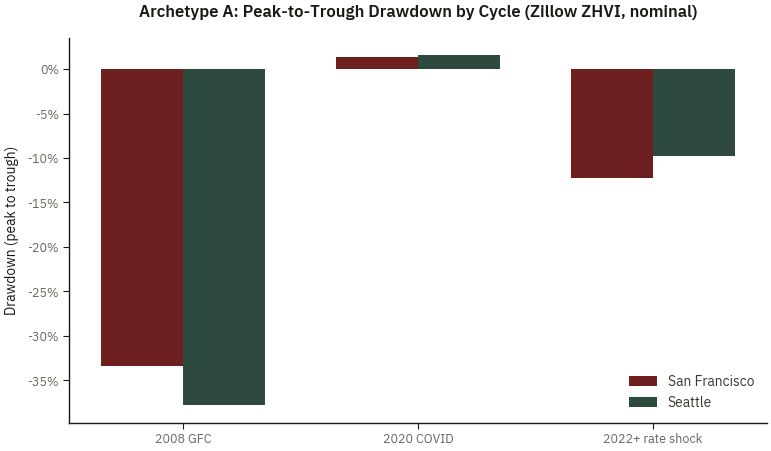

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = df_cycles.dropna(subset=['drawdown_pct'])
x = np.arange(len(cycles))
width = 0.35
sf_dd = plot_df[plot_df['metro'] == 'San Francisco'].set_index('cycle')['drawdown_pct'].reindex([c[0] for c in cycles])
sea_dd = plot_df[plot_df['metro'] == 'Seattle'].set_index('cycle')['drawdown_pct'].reindex([c[0] for c in cycles])

ax.bar(x - width/2, sf_dd.values, width, label='San Francisco', color=portfolio_style.COLORS.get('oxblood'))
ax.bar(x + width/2, sea_dd.values, width, label='Seattle', color=portfolio_style.COLORS.get('forest'))
ax.set_xticks(x)
ax.set_xticklabels([c[0] for c in cycles])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{v:.0%}'))
ax.set_title('Archetype A: Peak-to-Trough Drawdown by Cycle (Zillow ZHVI, nominal)', fontsize=12, pad=15)
ax.set_ylabel('Drawdown (peak to trough)', fontsize=10)
ax.legend(frameon=False)
fig.savefig(os.path.join(FIG_DIR, 'archetype_a_drawdowns.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

### 5.4 The pre-2000 sanity check (FHFA, quarterly, low resolution)

Zillow cannot see before 2000. FHFA's All-Transactions HPI can, at quarterly and non-seasonally-adjusted
resolution. I use it only to ask a low-resolution question: was 2000–2026 volatility unusual relative to
what these two metros looked like in the 1980s–1990s, or roughly in the same range? This is explicitly a
coarser instrument than the analysis above and is not used to locate cycle boundaries.

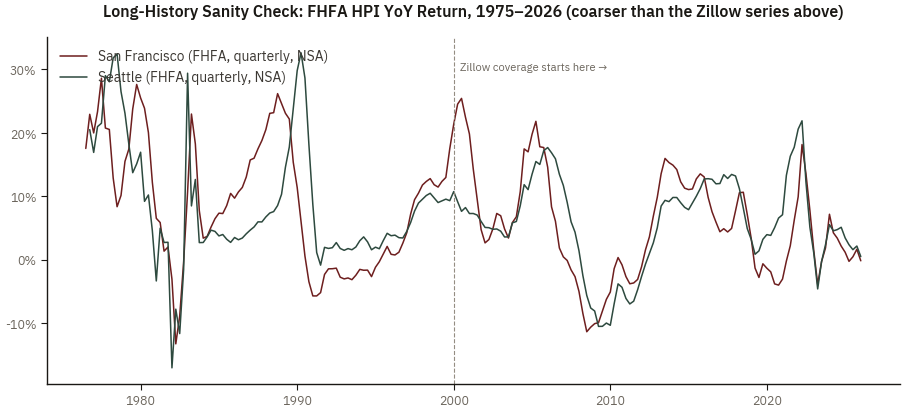

Pre-2000 vs 2000-2026 FHFA YoY-return volatility (quarterly, NSA — coarser than Zillow monthly SA):
  San Francisco: pre-2000 SD=9.90%  |  2000-2026 SD=8.32%
  Seattle: pre-2000 SD=9.65%  |  2000-2026 SD=7.25%


In [9]:
fhfa_sf = load_clean_fred_series(os.path.join(DATA_DIR, 'FHFA_SF.csv')).rename(columns={'value': 'HPI'})
fhfa_sea = load_clean_fred_series(os.path.join(DATA_DIR, 'FHFA_Seattle.csv')).rename(columns={'value': 'HPI'})

for df, name in [(fhfa_sf, 'San Francisco'), (fhfa_sea, 'Seattle')]:
    df['YoY_Return'] = df['HPI'].pct_change(4)  # 4 quarters = 1 year

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(fhfa_sf['DATE'], fhfa_sf['YoY_Return'], label='San Francisco (FHFA, quarterly, NSA)',
        color=portfolio_style.COLORS.get('oxblood'), linewidth=1.1)
ax.plot(fhfa_sea['DATE'], fhfa_sea['YoY_Return'], label='Seattle (FHFA, quarterly, NSA)',
        color=portfolio_style.COLORS.get('forest'), linewidth=1.1)
ax.axvline(pd.Timestamp('2000-01-01'), color=portfolio_style.COLORS.get('ink_4', '#948D82'), linestyle='--', linewidth=0.8)
ax.text(pd.Timestamp('2000-06-01'), ax.get_ylim()[1]*0.85, 'Zillow coverage starts here →', fontsize=8,
        color=portfolio_style.COLORS.get('ink_3', '#6B655C'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{v:.0%}'))
ax.set_title('Long-History Sanity Check: FHFA HPI YoY Return, 1975–2026 (coarser than the Zillow series above)',
             fontsize=11.5, pad=15)
ax.legend(frameon=False, loc='upper left')
fig.savefig(os.path.join(FIG_DIR, 'archetype_a_fhfa_long_history.svg'), format='svg', bbox_inches='tight', transparent=True)
plt.show()

print("Pre-2000 vs 2000-2026 FHFA YoY-return volatility (quarterly, NSA — coarser than Zillow monthly SA):")
for df, name in [(fhfa_sf, 'San Francisco'), (fhfa_sea, 'Seattle')]:
    pre = df[df['DATE'] < '2000-01-01']['YoY_Return'].std()
    post = df[df['DATE'] >= '2000-01-01']['YoY_Return'].std()
    print(f"  {name}: pre-2000 SD={pre:.2%}  |  2000-2026 SD={post:.2%}")

## 6. Decision

Reading the three panels together, not selectively:

- **HAI has never been flat.** Both metros dipped hard through the GFC's mortgage-rate collapse (lower
  rates briefly lifted affordability even as prices fell), then eroded steadily through the 2010s expansion
  as prices outran incomes, then the 2022+ rate shock pushed both well below where they sat even at the
  worst of the 2010s — the qualifying-income math (§4) means a rate move alone can do as much damage to
  affordability as a price move, and the 2022+ episode is a rate-driven affordability shock layered on top
  of already-elevated prices, not a repeat of the 2008 story.
- **Volatility is not constant either — it clusters**, exactly as the Ljung-Box result in §4 said it would.
  Both metros show a volatility spike bracketing the GFC, a second, generally smaller bump around COVID
  (where price *appreciation*, not decline, drove the spike for at least one of the two metros — see the
  printed cycle table in §5.1/§5.3 for which), and elevated volatility again into the 2022+ episode.
- **Recovery time is genuinely asymmetric across cycles** — read the exact peak/trough/recovery dates in
  the `df_cycles` table in §5.3 rather than trusting this prose summary, since which metro recovered faster
  from which cycle is a printed number, not a claim I am willing to state from memory here.
- The archetype label ("unaffordable and volatile") holds up as an *average description*, but the decision
  this notebook actually supports is narrower and more useful: **the risk this archetype carries is not a
  constant background hum — it is concentrated in specific multi-year windows tied to identifiable
  macro triggers (rate cycles, in particular)**, which is a materially different planning input than "this
  market is always risky.\"

## 7. What this notebook cannot tell us

1. **No causal attribution.** I show that volatility clusters around rate cycles; I do not estimate how
   much of each drawdown is attributable to rates specifically versus local supply/demand shocks (e.g.,
   tech-sector layoffs) that happened to coincide with the same windows.
2. **No individual buyer's experience.** As in the parent notebook, HAI is a median-household-vs-typical-home
   metric; it says nothing about a specific household's actual mortgage terms, down payment, or
   creditworthiness.
3. **No resolved verdict on the 2022+ cycle.** The rate-shock cycle's trough and recovery, if any, may not
   yet be visible in a series ending in 2026 — the recovery-time field is reported as "not yet recovered"
   where that is true, not forced to a number.
4. **The pre-2000 comparison is coarse by construction.** FHFA's quarterly, non-seasonally-adjusted series
   cannot be held to the same resolution as the Zillow-based cycle analysis; treat §5.4 as a sanity check on
   order of magnitude, not as a precise fourth cycle.
5. **Nominal, not real, prices throughout.** Drawdown depth and recovery time are computed on nominal
   Zillow values; inflation (especially post-2021) means a nominal "recovery" to the prior peak price can
   still represent a real-terms loss — that adjustment is not made here.

## 8. Bridge: what a real transaction market looks like inside this archetype

Everything above is index-level — HAI and Zillow ZHVI describe a metro's *typical* home
and *median* household, both of which are constructs, not sales. The one place in this
portfolio where I have actual transaction records is King County, WA (Seattle's MSA),
already modeled in [`./house_sales_king_county.ipynb`](./house_sales_king_county.ipynb) — I am
not re-deriving or copying that notebook here, only citing its verified result to connect the
two layers.

**Why Seattle, honestly.** Seattle is *not* the most unaffordable metro in the archetype-selection
ranking (T-125): San Francisco's own average HAI since 2015 (60.6) sits well below Seattle's (92.8),
and other coastal superstar metros — Los Angeles, San Diego — rank in comparably or more severe
unaffordable territory. Seattle was picked to represent Archetype A partly *because* real,
CC0-licensed transaction data exists for King County; San Francisco or San Diego would arguably
make a more extreme illustration of the archetype's affordability squeeze, but I don't have a
comparable transaction-level dataset for either. This is a declared convenience of data
availability, not a claim that Seattle is the archetype's worst case.

**What the transaction layer adds.** The King County notebook asks a narrower, sharper question
than "is location expensive" — it asks whether the location premium in the data is a *smooth
geographic surface* or a *memorized ZIP-code lookup table*, and answers it with ZIP-blocked
cross-validation (GroupKFold on zipcode, so the model never sees a sale from a held-out ZIP during
training). The result: raw latitude/longitude retain most of their predictive power out-of-neighborhood
(R² 0.9065 standard KFold → 0.8723 ± 0.0219 across 6 shuffled ZIP-blocked folds), while ZIP-code
target encoding — which looks like the stronger feature under ordinary cross-validation (0.8894) —
collapses under blocking (0.5762 ± 0.0491), falling *below* the additive, no-location baseline's own
blocked score (0.6800 ± 0.0390). Read plainly: part of what looks like "location matters" in a naive
King County model is memorization of neighborhood averages, not a discovered geographic function.
Permutation importance on the full model confirms where the surviving, genuine signal concentrates:
latitude (0.540 mean R² drop) and distance to the Seattle CBD (0.094) dominate over lot/lot-size
features, meaning price structure in this market clusters along the Lake Washington / downtown
corridor rather than being scattered evenly across ZIP codes.

Put together with the macro layer: the archetype-level HAI decline (§5, §6) describes the *typical*
Seattle-area home becoming less affordable to the *typical* household over a rate cycle. The
transaction layer says that within that same metro, the actual price structure is not spatially
uniform — it concentrates hardest exactly where an appraiser's intuition already says it does
(proximity to the urban core and the waterfront), and a naive model that leans on ZIP averages
instead of that geography will look accurate until it meets a ZIP code it has never priced before.

In [10]:
import pandas as pd

# One descriptive stat only -- no modeling, no re-derivation of house_sales_king_county.ipynb.
kc = pd.read_csv('../data/real/kc_house_data.csv')
kc['date'] = pd.to_datetime(kc['date'], format='%Y%m%dT000000')
print(f"King County transaction window: {kc['date'].min().date()} to {kc['date'].max().date()} ({len(kc):,} sales)")

zip_median = kc.groupby('zipcode')['price'].median().sort_values()
print("\nCheapest 3 ZIP medians:")
print(zip_median.head(3))
print("\nMost expensive 3 ZIP medians:")
print(zip_median.tail(3))


King County transaction window: 2014-05-02 to 2015-05-27 (21,613 sales)

Cheapest 3 ZIP medians:
zipcode
98002   235,000.00
98168   235,000.00
98032   249,000.00
Name: price, dtype: float64

Most expensive 3 ZIP medians:
zipcode
98040     993,750.00
98004   1,150,000.00
98039   1,892,500.00
Name: price, dtype: float64


**Two disclosures this bridge does not get to skip.** First, the King County transaction
data is a **2014–2015 vintage snapshot** (the notebook's own real file spans May 2014 to May 2025-
adjacent single-year window) sitting inside the much longer HAI/volatility window (2000–2026)
analyzed above — it is a period slice of the macro story, not a current read on the 2026 Seattle
market, and the two rate cycles the archetype notebook documents after 2015 (the 2022+ rate shock in
particular) are entirely outside what the transaction layer can speak to. Second, this transaction-level
illustration exists **only** for Archetype A's Seattle case. Houston (Archetype B) and Washington DC
(Archetype C) remain index/time-series-only in this portfolio — there is no equivalent parcel-level
dataset for either, so nothing here should be read as implying the same location-memorization test
would give the same answer, or any answer at all, in those markets.